# MLOps Assignment: Predictive Maintenance Classification
### Starter Notebook

**Domain:** Industrial IoT / Manufacturing
**Task:** Multi-class failure type prediction
**Tools:** Pandera, MLflow, Optuna, Evidently, SHAP

---

## Business Context

A heavy-equipment manufacturer runs 10,000+ machines on the shop floor.
Each machine continuously streams six sensor readings. When a machine fails,
production halts - at a cost of ₹8-15 lakh per hour of downtime.

Your job is to build a full MLOps pipeline that:
1. Validates incoming sensor data before it enters the pipeline (Pandera)
2. Trains and tracks a multi-class failure classifier (MLflow)
3. Tunes hyperparameters and registers the best model (Optuna + MLflow Registry)
4. Monitors the deployed model for distributional shift (Evidently)
5. Explains why the model predicts a specific failure type (SHAP)

**Files provided:**
- `data/train.csv`   - 6,993 labelled sensor readings (historical baseline)
- `data/current.csv` - 1,499 readings from the current stable production batch
- `data/stress.csv`  - 1,499 readings from a heavy-load production period

**Failure classes:**

| Code | Name | Description |
|------|------|-------------|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |

> Visual anchor: use the generated `eda_distributions.png` early (Section 1.3) to ground your expectations before drift and SHAP interpretation.
> Stress-batch goal: diagnose *why* the model is stale under shifted operating conditions, not to force perfect predictions on `stress.csv`.
> **Submission:** Submit this notebook (`.ipynb`) with all cells executed.
> Do not change the section structure or remove any markdown cells.

## Imports

In [20]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandera
import mlflow
import sklearn

In [ ]:
#conda create -n mlops_assignment python=3.11
#conda activate mlops_assignment
#pip install -r requirements.txt

## Environment Configuration

This project was developed using Python 3.11 to ensure stable compatibility and seamless integration with the required machine learning and MLOps libraries.

### Environment Details
- Python Version: 3.11
- Libraries managed using `requirements.txt`
- Environment created using Conda
- Package installation handled using `pip`

In [1]:
import sys
print(sys.version)

3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]


In [ ]:

print('pandera:', pandera.__version__)
print('mlflow:', mlflow.__version__)
print('sklearn:', sklearn.__version__)
print('pandas:', pandas.__version__)
print('numpy:', numpy.__version__)


pandera: 0.31.1
mlflow: 3.11.1
sklearn: 1.8.0
pandas: 2.3.3
numpy: 2.4.4


### Utility Functions

In [21]:
# =========================
# Utility Functions
# =========================

def plot_distribution(
    df,
    x_col=None,
    y_col=None,
    plot_type='bar',
    order=None,
    palette='viridis',
    hue=None,
    bins=30,
    figsize=(12, 6),
    title=None,
    rotation=45
):
    """
    Generic visualization function for EDA.
    
    Supported Plots:
    - bar
    - count
    - line
    - histogram
    - box
    
    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.
        
    x_col : str
        Column for x-axis.
        
    y_col : str, optional
        Column for y-axis.
        
    plot_type : str
        Type of plot:
        ['bar', 'count', 'line', 'histogram', 'box']
        
    order : list, optional
        Custom category order.
        
    palette : str
        Seaborn color palette.
        
    hue : str, optional
        Column used for grouping.
        
    bins : int
        Number of bins for histogram.
        
    figsize : tuple
        Figure size.
        
    title : str, optional
        Custom plot title.
        
    rotation : int
        X-axis label rotation.
    """

    plt.figure(figsize=figsize)

    # ---------------- BAR PLOT ---------------- #
    if plot_type == 'bar':

        sns.barplot(
            data=df,
            x=x_col,
            y=y_col,
            hue=hue,
            order=order,
            palette=palette
        )

        plt.ylabel(y_col.replace('_', ' ').title())

    # ---------------- COUNT PLOT ---------------- #
    elif plot_type == 'count':

        sns.countplot(
            data=df,
            x=x_col,
            hue=hue,
            order=order,
            palette=palette
        )

        plt.ylabel("Count")

    # ---------------- LINE PLOT ---------------- #
    elif plot_type == 'line':

        sns.lineplot(
            data=df,
            x=x_col,
            y=y_col,
            hue=hue,
            marker='o',
            palette=palette
        )

        plt.ylabel(y_col.replace('_', ' ').title())

    # ---------------- HISTOGRAM ---------------- #
    elif plot_type == 'histogram':

        sns.histplot(
            data=df,
            x=x_col,
            hue=hue,
            bins=bins,
            kde=True,
            palette=palette
        )

        plt.ylabel("Frequency")

    # ---------------- BOX PLOT ---------------- #
    elif plot_type == 'box':

        sns.boxplot(
            data=df,
            x=x_col,
            y=y_col,
            hue=hue,
            order=order,
            palette=palette
        )

        plt.ylabel(y_col.replace('_', ' ').title())

    else:
        raise ValueError(
            "plot_type must be one of "
            "['bar', 'count', 'line', 'histogram', 'box']"
        )

    # ---------------- TITLES & LABELS ---------------- #

    if title:
        plt.title(title)
    else:
        plt.title(
            f"{plot_type.title()} Plot"
        )

    if x_col:
        plt.xlabel(x_col.replace('_', ' ').title())

    plt.xticks(rotation=rotation)

    # ---------------- VALUE LABELS ---------------- #

    ax = plt.gca()

    if plot_type in ['bar', 'count'] and hue is None:

        for p in ax.patches:

            height = p.get_height()

            ax.annotate(
                f'{height:,.0f}',
                (
                    p.get_x() + p.get_width() / 2.,
                    height
                ),
                ha='center',
                va='bottom',
                fontsize=9,
                xytext=(0, 5),
                textcoords='offset points'
            )

    plt.tight_layout()
    plt.show()

## **1. Data Loading, Schema Validation & EDA** <font color=red>[15 marks]</font>

### **1.1** <font color=red>[3 marks]</font> Load the datasets

Load `train.csv`, `current.csv`, and `stress.csv` from the `data/` folder.
Print the shape of each and display the first 5 rows of the training set.


In [12]:
import os
os.chdir("d:\\Projects\\GitHub\\MLOpsAssignment\\src")
os.getcwd()
import json

with open("config/config.json") as f:
    config = json.load(f)

print(f"OS Enviornment: {os.environ}")

if "COLAB_GPU" in os.environ:
    env = "colab"
else:
    env = config["env"]

paths = config["paths"][env]

print(paths)

OS Enviornment: environ({'ALLUSERSPROFILE': 'C:\\ProgramData', 'APPDATA': 'C:\\Users\\DELL\\AppData\\Roaming', 'APPLICATIONINSIGHTS_CONFIGURATION_CONTENT': '{}', 'APPLICATION_INSIGHTS_NO_DIAGNOSTIC_CHANNEL': '1', 'CHOCOLATEYINSTALL': 'C:\\ProgramData\\chocolatey', 'CHOCOLATEYLASTPATHUPDATE': '133599196061428989', 'CHROME_CRASHPAD_PIPE_NAME': '\\\\.\\pipe\\crashpad_13908_YAGHXWAMBRWEUPGH', 'COMMONPROGRAMFILES': 'C:\\Program Files\\Common Files', 'COMMONPROGRAMFILES(X86)': 'C:\\Program Files (x86)\\Common Files', 'COMMONPROGRAMW6432': 'C:\\Program Files\\Common Files', 'COMPUTERNAME': 'DESKTOP-C66A8O2', 'COMSPEC': 'C:\\WINDOWS\\system32\\cmd.exe', 'CONDA_DEFAULT_ENV': 'mlops_assignment', 'CONDA_EXE': 'C:\\Users\\DELL\\miniconda3\\Scripts\\conda.exe', 'CONDA_PREFIX': 'C:\\Users\\DELL\\miniconda3\\envs\\mlops_assignment', 'CONDA_PROMPT_MODIFIER': '(mlops_assignment) ', 'CONDA_PYTHON_EXE': 'C:\\Users\\DELL\\miniconda3\\python.exe', 'CONDA_ROOT': 'C:\\Users\\DELL\\miniconda3', 'CONDA_SHLVL':

In [ ]:
# TODO: Load the three datasets

train   = pd.read_csv(paths["train"])
current = pd.read_csv(paths["current"])
stress  = pd.read_csv(paths["stress"])

# TODO: Print shapes
print(f'train  : {train.shape}')
print(f'current: {current.shape}')
print(f'stress : {stress.shape}')

CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

# TODO: Display first 5 rows of train
train.head()


train  : (6993, 7)
current: (1499, 7)
stress : (1499, 7)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type
0,L,302.5,311.1,1499,38.8,135,0
1,L,297.3,308.4,1469,46.7,65,0
2,L,297.3,308.5,1504,42.0,142,0
3,L,299.6,309.5,1803,27.7,159,0
4,L,301.1,311.1,1387,53.1,188,0


### **1.2** <font color=red>[5 marks]</font> Define and apply a Pandera schema

Define a `DataFrameSchema` enforcing the domain constraints below.
Validate `train` and `current` (must pass). Validate `stress` with `lazy=True`.

| Column | Type | Constraint |
|--------|------|------------|
| Type | str | one of L, M, H |
| Air temperature | float | [295.0, 305.0] K |
| Process temperature | float | [305.0, 315.0] K |
| Rotational speed | int64 | [1000, 2900] rpm |
| Torque | float | [3.0, 80.0] Nm |
| Tool wear | int64 | [0, 253] min |
| Failure_Type | int64 | 0, 1, 2, 3, 4 |


> `stress.csv` may still pass schema validation. That is fine: it is designed to be valid but drifted.
> Hint: valid data can still be statistically unusual. Before Section 3, compare the mean of `Rotational speed` in `current` vs `stress`.

#### Schema Validation Function

A reusable validation function was created using `pandera` to validate datasets against predefined schema constraints and generate a summarized report of validation violations.

In [16]:
import pandera as pa

def validate_dataset(dataset, dataset_name, schema):
    """
    Validate dataset using Pandera schema and print violation summary.
    """
    
    try:
        schema.validate(dataset, lazy=True)
        print(f"{dataset_name} validation passed.\n")
        
    except pa.errors.SchemaErrors as e:
        
        print(f"{dataset_name} validation failed.\n")
        print("Violation Summary:\n")
        
        violation_summary = (
            e.failure_cases[
                ["column", "check", "failure_case"]
            ]
            .drop_duplicates()
        )
        
        print(violation_summary)

In [17]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# TODO: Define the schema
schema = DataFrameSchema({
    "Type": Column(
        str,
        Check.isin(["L", "M", "H"])
    ),

    "Air temperature": Column(
        float,
        Check.in_range(295.0, 305.0)
    ),

    "Process temperature": Column(
        float,
        Check.in_range(305.0, 315.0)
    ),

    "Rotational speed": Column(
        int,
        Check.in_range(1000, 2900)
    ),

    "Torque": Column(
        float,
        Check.in_range(3.0, 80.0)
    ),

    "Tool wear": Column(
        int,
        Check.in_range(0, 253)
    ),

    "Failure_Type": Column(
        int,
        Check.isin([0, 1, 2, 3, 4])
    )
})

def fix_dtypes(df):
    df = df.copy()
    df['Rotational speed'] = df['Rotational speed'].astype('int64')
    df['Tool wear']        = df['Tool wear'].astype('int64')
    df['Failure_Type']     = df['Failure_Type'].astype('int64')
    return df

train   = fix_dtypes(train)
current = fix_dtypes(current)
stress  = fix_dtypes(stress)

# TODO: Validate train and current
schema.validate(train)
schema.validate(current)

# TODO: Validate stress with lazy=True and print violation summary
validate_dataset(train, "Train Dataset", schema)

validate_dataset(current, "Current Dataset", schema)

validate_dataset(stress, "Stress Dataset", schema)

Train Dataset validation passed.

Current Dataset validation passed.

Stress Dataset validation passed.



ℹ️ Validation Observation

All datasets successfully passed schema validation, indicating that the data conforms to the predefined structural and domain constraints.

However, schema validation alone does not guarantee statistical consistency with the training data. A dataset may remain valid while still exhibiting distributional drift, which is evaluated separately in subsequent sections.

### **1.3** <font color=red>[4 marks]</font> Exploratory Data Analysis

1. Print the class distribution of `Failure_Type`. Is it balanced?
2. Plot the distribution of `Torque` and `Tool wear` split by failure class (failures only).
3. Print the `Type` (L/M/H) distribution.


#### 📊 Class distribution (print + bar chart)

Failure Type Distribution:

Failure_Type
0    6762
1      30
2      76
3      56
4      69
Name: count, dtype: int64

Percentage Distribution:

Failure_Type
0    96.70
1     0.43
2     1.09
3     0.80
4     0.99
Name: count, dtype: float64


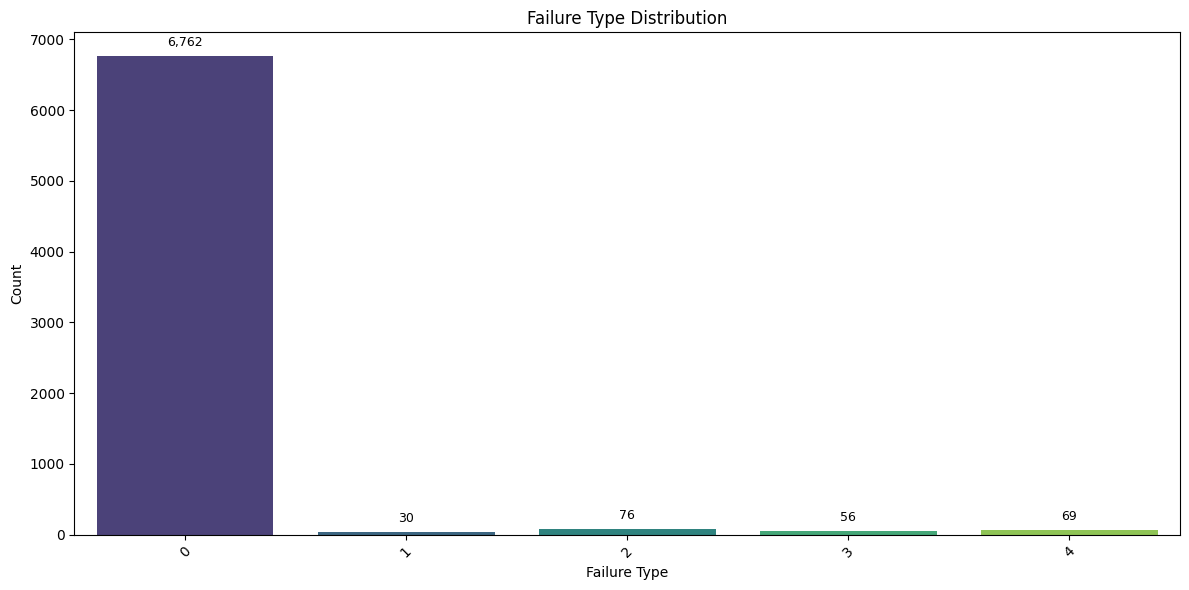

In [ ]:
# Finding Failure Distribution
failure_distribution=train["Failure_Type"].value_counts().sort_index()

print("Failure Type Distribution:\n")
print(failure_distribution)

print("\nPercentage Distribution:\n")
print(
     round(
        (failure_distribution / failure_distribution.sum()) * 100,
        2
    )
)

# Bar chart to show the class distribution
plot_distribution(
    df=train,
    x_col="Failure_Type",
    plot_type="count",
    title="Failure Type Distribution"
)

ℹ️ Observation: The dataset is highly imbalanced, with the majority class (`Failure_Type = 0`) accounting for approximately 96.7% of the observations, while all failure classes collectively represent only a small portion of the dataset. This imbalance may impact model learning and evaluation, making techniques such as stratified sampling, class weighting, or imbalance handling important during model training.

#### 📊 Torque distribution by failure type (histogram, failures only)

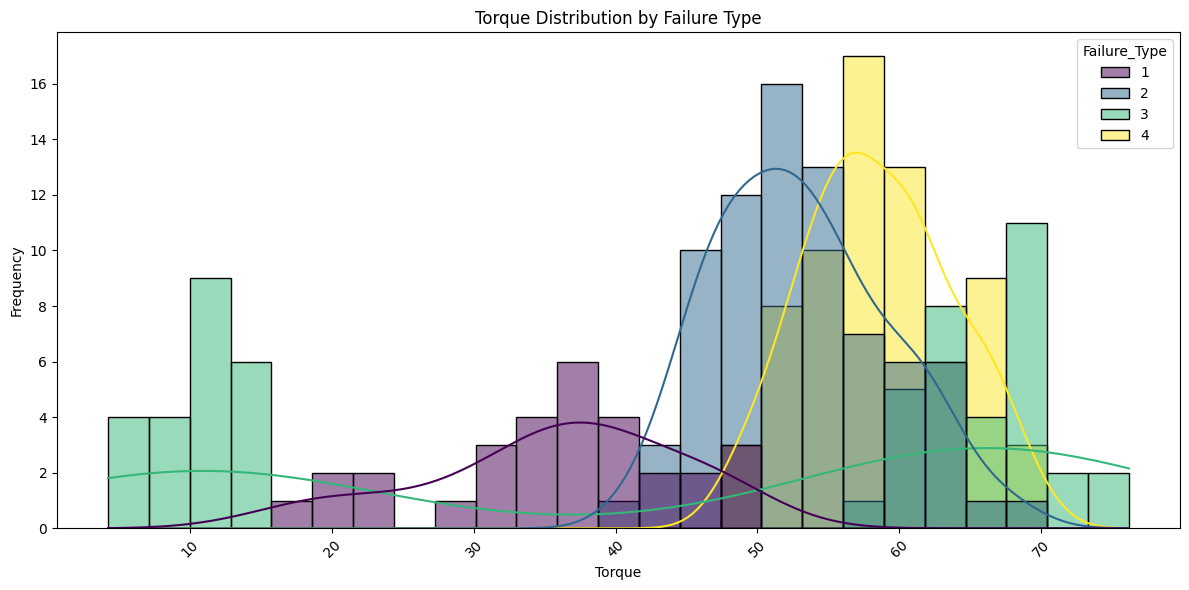

In [ ]:
# Filter failure records only
failure_data = train[train["Failure_Type"]!=0]

plot_distribution(
    df=failure_data,
    x_col="Torque",
    plot_type="histogram",
    hue="Failure_Type",
    bins=25,
    title="Torque Distribution by Failure Type"
)

ℹ️ Observation: The torque distributions differ noticeably across failure types. Failure types 2 and 4 are concentrated around the mid-to-high torque range (approximately 50–65 Nm), while failure type 1 is more associated with lower torque values. Failure type 3 shows a wider spread across both low and high torque ranges, indicating greater variability in operational conditions leading to that failure category.

#### 📊 Tool wear distribution by failure type

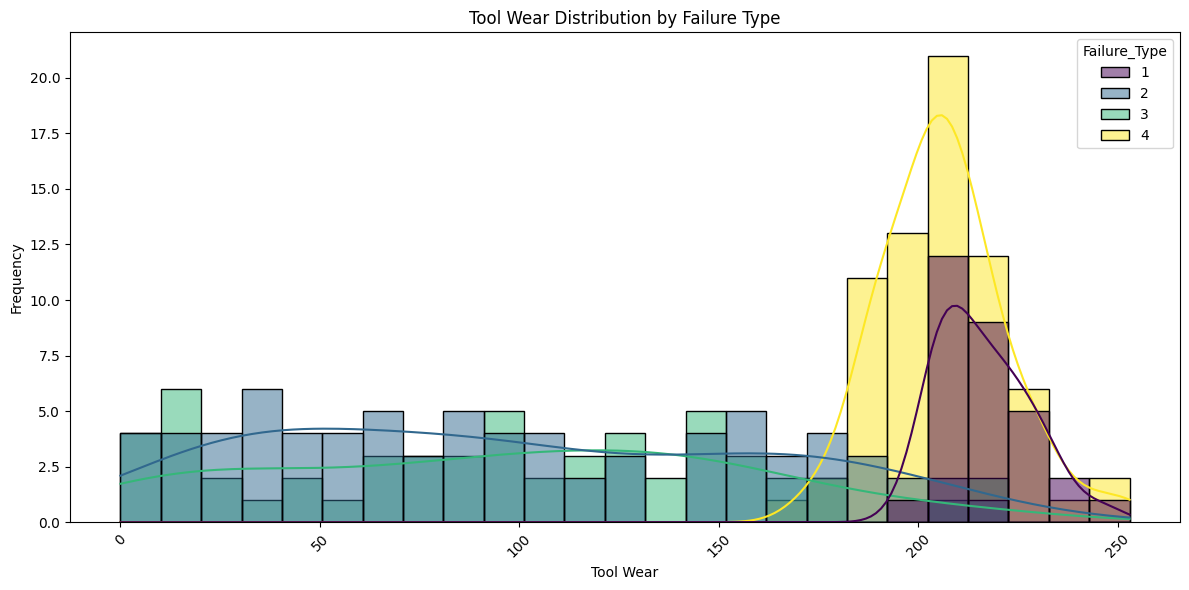

In [ ]:

plot_distribution(
    df=failure_data,
    x_col="Tool wear",
    plot_type="histogram",
    hue="Failure_Type",
    bins=25,
    title="Tool Wear Distribution by Failure Type"
)

ℹ️ Observation: Failure types 1 and 4 are primarily concentrated at higher tool wear values, particularly around the 190–230 range, indicating a stronger relationship between increased tool wear and these failure categories. In contrast, failure types 2 and 3 are distributed more broadly across lower and mid-range wear values, suggesting differing operational behavior among failure types.

#### 📊 Type Distribution Analysis

Type Distribution:

Type
L    4213
M    2074
H     706
Name: count, dtype: int64

Percentage Distribution:

Type
L    60.25
M    29.66
H    10.10
Name: count, dtype: float64


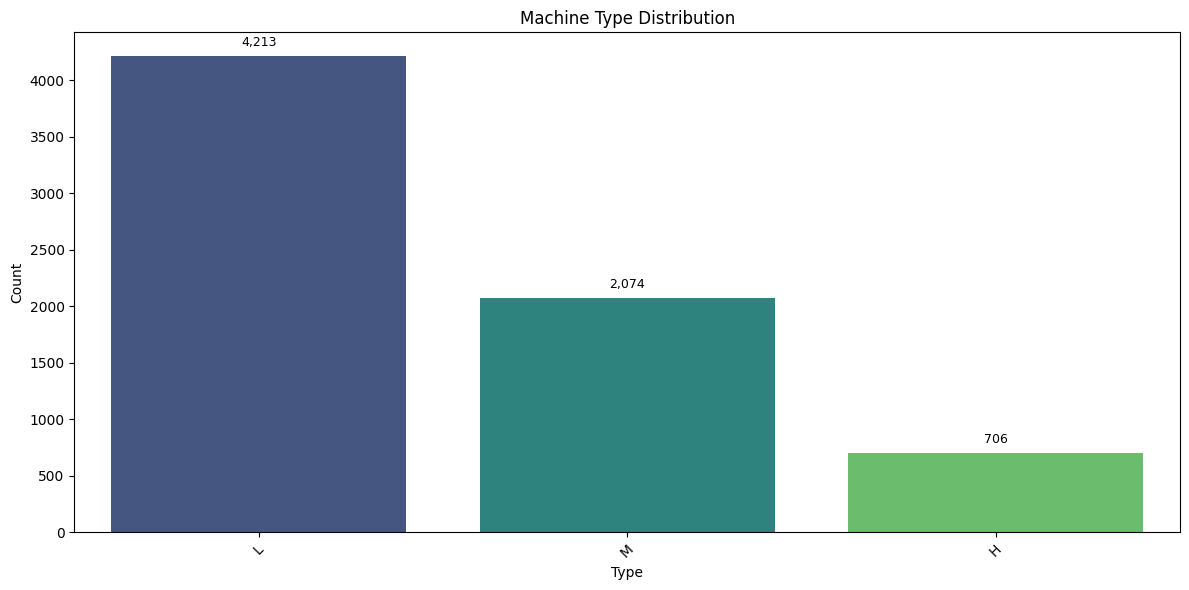

In [27]:
type_distribution = (
    train["Type"]
    .value_counts()
)

# Print distribution
print("Type Distribution:\n")
print(type_distribution)

print("\nPercentage Distribution:\n")
print(
    round(
        (type_distribution / type_distribution.sum()) * 100,
        2
    )
)

plot_distribution(
    df=train,
    x_col="Type",
    plot_type="count",
    title="Machine Type Distribution"
)

ℹ️ Observation: Machine type `L` represents the majority of the dataset (approximately 60%), followed by `M` (~30%) and `H` (~10%). This indicates a moderate categorical imbalance, which may influence model learning and the representation of failure behavior across machine types.

### **1.4** <font color=red>[3 marks]</font> Feature Engineering

Compute the following derived features for all three datasets:

**Mechanical power** (Watts):
$$P = \text{Torque} \times \frac{\text{Rotational speed} \times 2\pi}{60}$$

**Temperature differential**:
$$\Delta T = \text{Process temperature} - \text{Air temperature}$$

Print the mean of each new feature grouped by `Failure_Type`.


In [29]:
def engineer_features(df):
    df = df.copy()
    
    #Computing Mechanical Power
    df["Power_W"] = (
        df["Torque"] * (df["Rotational speed"] * 2 * np.pi) / 60
    )

    #Computing Temperature differential
    df["Temp_diff"] =(df["Process temperature"] - df["Air temperature"])
    
    return df

train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)


#Print Grouped mean by failure type
grouped_mean = (
    train
    .groupby("Failure_Type")[
        ["Torque", "Tool wear", "Power_W", "Temp_diff"]
    ]
    .mean()
    .round(2)
)

print("Grouped Mean by Failure Type:\n")
display(
    grouped_mean.style
    .background_gradient(cmap="Blues")
    .format("{:.2f}")
)

Grouped Mean by Failure Type:



,Torque,Tool wear,Power_W,Temp_diff
Failure_Type,,,,
0,39.65,106.40,6248.24,10.01
1,35.66,216.20,5763.09,9.97
2,53.00,97.68,7403.55,8.23
3,43.42,95.54,6664.38,9.82
4,58.54,206.23,8216.07,10.07


ℹ️ Observation: Distinct operational patterns can be observed across failure categories. Failure types 2 and 4 exhibit notably higher average torque and mechanical power, suggesting that these failures are associated with heavier machine workloads. In contrast, failure types 1 and 4 show significantly higher average tool wear, indicating a stronger relationship between prolonged tool usage and failure occurrence. Temperature differential remains relatively stable across categories, implying that thermal variation may have a comparatively smaller influence on failure differentiation.

## **2. Experiment Tracking & Model Selection** <font color=red>[15 marks]</font>

### **2.1** <font color=red>[2 marks]</font> Setup: features, split, SMOTE

Use the features below. Apply a stratified 80/20 train-val split (random_state=42).
Apply SMOTE to the training split only. Print the post-SMOTE class distribution.

```
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
```

> In a markdown cell below the code, explain in 2–3 sentences why SMOTE is applied
> only to the training split and not the validation set.


#### 🎯Encode Type column

In [31]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

le = LabelEncoder()
train['Type_enc']   = le.fit_transform(train['Type'])
current['Type_enc'] = le.transform(current['Type'])
stress['Type_enc']  = le.transform(stress['Type'])

FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']

#### 🎯 Define X and y

In [32]:
TARGET = 'Failure_Type'


# Define features and target
X_train = train[FEATURES]
y_train = train[TARGET]

X_current = current[FEATURES]
y_current = current[TARGET]

X_stress = stress[FEATURES]
y_stress = stress[TARGET]

#### 🔀 Train-Validation Split

In [33]:
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

ℹ️ Observation: The dataset was split into training and validation subsets using stratified sampling to preserve the original class distribution across failure categories. This helps ensure more reliable and representative model evaluation.

#### 🎯 Apply SMOTE (k_neighbors=3, random_state=42)

In [34]:
smote = SMOTE(
    k_neighbors=3,
    random_state=42
)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

#### 🎯 Print post-SMOTE class distribution

In [37]:
#Print Class Distribution
print(pd.Series(y_train_resampled).value_counts().sort_index())

#Print Class Distribution Percentage-wise
print(pd.Series(y_train_resampled).value_counts(normalize=True).sort_index() * 100)

Failure_Type
0    6762
1    6762
2    6762
3    6762
4    6762
Name: count, dtype: int64
Failure_Type
0    20.0
1    20.0
2    20.0
3    20.0
4    20.0
Name: proportion, dtype: float64


*Your explanation here: why is SMOTE applied only on the training split?*
*<br/>SMOTE is applied only on the training data to prevent data leakage. Since SMOTE generates synthetic samples based on relationships between existing data points in the feature space, applying it before splitting would allow information from the validation or test sets to indirectly influence the training process. This leads to overly optimistic evaluation results and does not reflect real-world performance. Therefore, to ensure proper model generalization and unbiased evaluation, SMOTE must be applied only after splitting the dataset, and only on the training set.*

### **2.2** <font color=red>[8 marks]</font> Train and log 4 models with MLflow

Train and evaluate:
- Logistic Regression
- Random Forest (n_estimators=100)
- XGBoost (n_estimators=100)
- LightGBM (n_estimators=100)

MLflow experiment name: `PredMaint_ModelSelection`

For each run log: `model` (param), `macro_f1`, `weighted_f1`, `accuracy` (metrics),
and per-class F1 for all 5 classes. Print a comparison table. Pick the best model by macro F1.


In [38]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('PredMaint_ModelSelection')

CLASS_LIST = [0, 1, 2, 3, 4]
results = {}

models_to_run = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, random_state=42,
                                  class_weight='balanced'))
    ]),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42,
                                                  class_weight='balanced'),
    'XGBoost':            XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='mlogloss', verbosity=0),
    'LightGBM':           LGBMClassifier(n_estimators=100, random_state=42,
                                          class_weight='balanced', verbose=-1),
}

# TODO: For each model:
#   - Start an MLflow run
#   - Fit on X_res, y_res
#   - Predict on X_val
#   - Compute and log macro_f1, weighted_f1, accuracy, per-class F1
#   - Log the model artefact (use input_example=X_val.iloc[:5])

# TODO: Print comparison table
# TODO: Identify best model by macro F1


2026/05/09 18:53:48 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/09 18:53:48 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
INFO  [alembic.runtime.migration] Running upgrade 7ac759974ad8 -> 89d4b8295536, create latest metrics table
INFO  [89d4b8295536_create_latest_metrics_table_py] Migration complete!
INFO  

In [41]:
# For sake of naming convention, assigning SMOTE output to X_res and y_res
X_res = X_train_resampled
y_res = y_train_resampled

for name, model in models_to_run.items():

    with mlflow.start_run(run_name=name):

        #Train model
        model.fit(X_res, y_res)

        #Predict
        y_pred = model.predict(X_val)

        #Metrics
        acc = accuracy_score(y_val, y_pred)
        f1_macro = f1_score(y_val, y_pred, average='macro')
        f1_weighted = f1_score(y_val, y_pred, average='weighted')

        report = classification_report(y_val, y_pred, output_dict=True)

        #per-class F1
        per_class_f1 = {
            str(cls): report[str(cls)]['f1-score']
            for cls in CLASS_LIST
        }

        #Log metrics
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_macro", f1_macro)
        mlflow.log_metric("f1_weighted", f1_weighted)
        
        #store for comparison table
        results[name] = {
            "Accuracy": acc,
            "Macro_F1": f1_macro,
            "Weighted_F1": f1_weighted
        }

        for cls, f1 in per_class_f1.items():
            mlflow.log_metric(f"f1_class_{cls}", f1)

        #Log model
        mlflow.sklearn.log_model(
            model,
            artifact_path="model",
            input_example=X_val.iloc[:5]
        )

        #Print summary 
        print(f"\n===== {name} =====")
        print(f"Accuracy: {acc}")
        print(f"Macro F1: {f1_macro}")
        print(f"Weighted F1: {f1_weighted}")


===== LogisticRegression =====
Accuracy: 0.9092208720514653
Macro F1: 0.5459349653433774
Weighted F1: 0.9357607288064136



===== RandomForest =====
Accuracy: 1.0
Macro F1: 1.0
Weighted F1: 1.0



===== XGBoost =====
Accuracy: 1.0
Macro F1: 1.0
Weighted F1: 1.0



===== LightGBM =====
Accuracy: 1.0
Macro F1: 1.0
Weighted F1: 1.0


#### 🟢 Print comparison table

In [43]:
# results_df = pd.DataFrame(
#     list(results.items()),
#     columns=["Model", "Macro_F1"]
# ).sort_values(by="Macro_F1", ascending=False)

results_df = pd.DataFrame.from_dict(results, orient="index")

results_df = results_df.sort_values(by="Macro_F1", ascending=False)

display(results_df.sort_values("Macro_F1", ascending=False))

,Accuracy,Macro_F1,Weighted_F1
RandomForest,1.000000,1.000000,1.000000
XGBoost,1.000000,1.000000,1.000000
LightGBM,1.000000,1.000000,1.000000
LogisticRegression,0.909221,0.545935,0.935761


#### 🏆 Identify best model by macro F1

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

### **2.3** <font color=red>[5 marks]</font> Optuna tuning + MLflow Model Registry

Run an Optuna study (30 trials, `TPESampler(seed=42)`) tuning XGBoost hyperparameters.
Optimise for `macro_f1` on `X_val`.

MLflow experiment: `PredMaint_Optuna`

Register the best model as `PredMaint_XGBoost` and promote it to the `production` alias.
Print the improvement in macro F1 over the baseline XGBoost.


In [ ]:
import optuna
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_experiment('PredMaint_Optuna')

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0,
    }
    # TODO: Train XGBoost model, return macro_f1 on X_val

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
# TODO: Run study.optimize

# TODO: Train final best model
# TODO: Log to MLflow, register as 'PredMaint_XGBoost', promote to production alias
# TODO: Save with joblib.dump


## **3. Drift Detection & Monitoring** <font color=red>[10 marks]</font>

> Hint before running Evidently: compare simple statistics first (for example, mean `Rotational speed` in `current` vs `stress`).
> Reminder: passing Pandera only means values are valid; it does **not** mean the batch is in-distribution.
> Section objective: identify why the deployed model is stale on stress conditions.

### **3.1** <font color=red>[4 marks]</font> Evidently — current batch

Reference: `train[FEAT_COLS]` | Current: `current[FEAT_COLS]`

```
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
```

Run `DataDriftPreset`. Save HTML to `drift_current.html`.
Report: drift detected? How many features drifted?


In [ ]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']

# TODO: Run Evidently on current batch, save drift_current.html, print summary


### **3.2** <font color=red>[4 marks]</font> Evidently - stress batch

Repeat for `stress.csv`. Use `ColumnDriftMetric` for individual feature scores.
Save as `drift_stress.html`.
Print a table: feature | drift detected | Wasserstein score | ref mean | current mean | delta.

Focus question: this section is about diagnosing *staleness risk* (what shifted and why), not "making stress predictions look good."

In [ ]:
from evidently.legacy.metrics.data_drift.dataset_drift_metric import DatasetDriftMetric
from evidently.legacy.metrics.data_drift.column_drift_metric import ColumnDriftMetric

# TODO: Run Evidently on stress batch with per-column metrics
# TODO: Save drift_stress.html
# TODO: Print per-column drift table


### **3.3** <font color=red>[2 marks]</font> Retraining decision

Answer the following in a markdown cell:
1. Which features drifted in the stress batch?
2. Cross-referencing with your SHAP results (Section 4) ? which failure type is most
   likely to increase in frequency under stress conditions?
3. Should the model be retrained? Justify with evidence from Sections 3.1, 3.2, and 4.

Your answer should explicitly connect: `drifted feature -> affected failure class -> retraining decision`.

**Your answer here:**

1. Features that drifted: ...
2. Most likely failure type to increase: ...
3. Retraining recommendation: ...


## **4. Explainability & Insights** <font color=red>[5 marks]</font>

> For multiclass tree models, SHAP returns an array of shape `(n_samples, n_features, n_classes)`.
>
> **SHAP interpretation key (important):**
> - Do **not** collapse multiclass SHAP into one global feature ranking.
> - Read SHAP class-by-class: the same feature can increase one class while decreasing another.
> - Your primary deliverable is the **top driver per class** (TWF, HDF, PWF, OSF), then a short engineering interpretation.

### **4.1** <font color=red>[3 marks]</font> SHAP analysis per failure class

Load `best_model.pkl`. Use `shap.TreeExplainer` on `train[FEATURES]`.
Plot mean |SHAP| bar charts for TWF, HDF, PWF, OSF (4 subplots). Save as `shap_per_class.png`.
Print the top driver for each failure class.

Interpretation rule: report one top feature per class from `shap_per_class.png`; avoid a single cross-class "global winner."

In [ ]:
import shap

best_model = joblib.load('best_model.pkl')

# TODO: Compute SHAP values using TreeExplainer
# TODO: Plot 4-subplot bar chart (one per failure class)
# TODO: Save shap_per_class.png
# TODO: Print top driver per class


### **4.2** <font color=red>[2 marks]</font> Engineering insight

Answer in this markdown cell:

1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed`
   in SHAP importance for **PWF**?
2. How does `Temp_diff` rank for **HDF** vs other failure types?
3. In 2-3 sentences, describe the physical mechanism behind each failure type based on SHAP.

Suggested structure for your actionable recommendation (used again in Section 5.1.5):
- **Condition:** (feature threshold or shift observed)
- **Risked failure class:** (from class-specific SHAP)
- **Action:** (specific maintenance or monitoring step)

**Your answer here:**

1. Power_W for PWF: ...
2. Temp_diff for HDF: ...
3. Physical mechanisms: ...


## **5. Conclusions** <font color=red>[5 marks]</font>

### **5.1** <font color=red>[5 marks]</font> Key findings

Write a structured conclusion (1 mark per point):

1. Which model won and why - reference macro F1 numbers.
2. Why accuracy is misleading here - operational cost implication.
3. TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.
   - Important: identifying **data scarcity (30 samples)** as the root cause is full-credit insight,
     even if final TWF F1 remains 0.0.
4. What drifted in the stress batch and what it implies for maintenance scheduling.
5. One actionable recommendation for the engineering team based on SHAP.

## Conclusions

**1. Model selection:**
...

**2. Accuracy vs Macro F1:**
...

**3. The TWF problem:**
State this as a data engineering limitation first (rare class with only 30 real samples),
then propose what data should be collected next.

**4. Drift and maintenance schedule:**
...

**5. Actionable recommendation:**
Use this format: Condition -> Risked failure class -> Action.